# 5. Phylogenetic Diversity Analysis
xxx

In [2]:
# 1- Import packages
import os
import pandas as pd
from qiime2 import Visualization
import matplotlib.pyplot as plt
import numpy as np
import qiime2 as q2
%matplotlib inline

In [3]:
# 2 - Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [8]:
# 3 - Data directories
raw_data_dir = "../data/raw"
phylogeny_data_dir = "../data/processed/phylogeny"
denoising_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"

phylogenetic_diversity_data_dir = "../data/processed/phylogenetic_diversity"

## Core Metrics (all ages)

In [24]:
! qiime tools peek $phylogeny_data_dir/sepp-tree.qza

UUID:        2668cfca-0322-462b-a652-2a9dca8a799f
Type:        Phylogeny[Rooted]
Data format: NewickDirectoryFormat


In [25]:
! qiime diversity core-metrics-phylogenetic \
  --i-table $denoising_data_dir/dada2_table.qza \
  --i-phylogeny $phylogeny_data_dir/sepp-tree.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-sampling-depth 10000 \
  --output-dir $phylogenetic_diversity_data_dir/core-metrics-results

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/phylogenetic_diversity/core-metrics-results/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-results/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-results/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-results/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-results/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/phylogenetic_diversity/core-me

In [35]:
! qiime diversity alpha-group-significance \
  --i-alpha-diversity $phylogenetic_diversity_data_dir/core-metrics-results/faith_pd_vector.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/faith-pd-group-significance.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/faith-pd-group-significance.qzv


In [5]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/faith-pd-group-significance.qzv")

<visualization: Visualization uuid: 44134cd2-469d-45b4-89ab-a76af01df308>

In [26]:
! qiime emperor plot \
  --i-pcoa $phylogenetic_diversity_data_dir/core-metrics-results/unweighted_unifrac_pcoa_results.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/unweighted-unifrac-emperor.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/unweighted-unifrac-emperor.qzv


In [6]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/unweighted-unifrac-emperor.qzv")

<visualization: Visualization uuid: 7ae30dfa-df1b-4983-9dd8-7fef80cae645>

In [29]:
! qiime emperor plot \
  --i-pcoa $phylogenetic_diversity_data_dir/core-metrics-results/weighted_unifrac_pcoa_results.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/weighted-unifrac-emperor.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/weighted-unifrac-emperor.qzv


In [34]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/weighted-unifrac-emperor.qzv")

<visualization: Visualization uuid: 34ecead1-ff65-4f4a-9d3e-6f8c55fdb6bf>

## Core Metrics (4 months)

In [38]:
! qiime feature-table filter-samples \
  --i-table $denoising_data_dir/dada2_table.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-where "age_months = 4.0" \
  --o-filtered-table $phylogenetic_diversity_data_dir/table-age4.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/phylogenetic_diversity/table-age4.qza


In [40]:
! qiime feature-table summarize \
  --i-table $phylogenetic_diversity_data_dir/table-age4.qza \
  --o-visualization $phylogenetic_diversity_data_dir/table-age4-summary.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/table-age4-summary.qzv


In [51]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/table-age4-summary.qzv")

<visualization: Visualization uuid: ef647556-be72-42ff-a261-6712d95133d4>

In [39]:
! qiime diversity core-metrics-phylogenetic \
  --i-table $phylogenetic_diversity_data_dir/table-age4.qza \
  --i-phylogeny $phylogeny_data_dir/sepp-tree.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-sampling-depth 10000 \
  --output-dir $phylogenetic_diversity_data_dir/core-metrics-age4-results

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/phylogenetic_diversity/core-metrics-age4-results/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age4-results/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age4-results/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age4-results/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age4-results/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/phylo

In [42]:
! qiime diversity alpha-group-significance \
  --i-alpha-diversity $phylogenetic_diversity_data_dir/core-metrics-age4-results/faith_pd_vector.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/faith-pd-age4-group-significance.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/faith-pd-age4-group-significance.qzv


In [27]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/faith-pd-age4-group-significance.qzv")

<visualization: Visualization uuid: 55df792b-cd1e-407a-a4e9-901253f280a8>

In [44]:
! qiime emperor plot \
  --i-pcoa $phylogenetic_diversity_data_dir/core-metrics-age4-results/unweighted_unifrac_pcoa_results.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/unweighted-unifrac-age4-emperor.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/unweighted-unifrac-age4-emperor.qzv


In [46]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/unweighted-unifrac-age4-emperor.qzv")

<visualization: Visualization uuid: 20143458-11ab-4f5e-8954-f8e419e16037>

In [48]:
! qiime emperor plot \
  --i-pcoa $phylogenetic_diversity_data_dir/core-metrics-age4-results/weighted_unifrac_pcoa_results.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/weighted-unifrac-age4-emperor.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/weighted-unifrac-age4-emperor.qzv


In [28]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/weighted-unifrac-age4-emperor.qzv")

<visualization: Visualization uuid: ea15c6b5-7b4d-4c12-a895-e942c05ef2de>

## Core Metrics (10 months)

In [50]:
! qiime feature-table filter-samples \
  --i-table $denoising_data_dir/dada2_table.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-where "age_months = 10.0" \
  --o-filtered-table $phylogenetic_diversity_data_dir/table-age10.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/phylogenetic_diversity/table-age10.qza


In [52]:
! qiime feature-table summarize \
  --i-table $phylogenetic_diversity_data_dir/table-age10.qza \
  --o-visualization $phylogenetic_diversity_data_dir/table-age10-summary.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/table-age10-summary.qzv


In [53]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/table-age10-summary.qzv")

<visualization: Visualization uuid: e69249d5-f4cc-4820-9d9e-99ee30310378>

In [61]:
! qiime diversity core-metrics-phylogenetic \
  --i-table $phylogenetic_diversity_data_dir/table-age10.qza \
  --i-phylogeny $phylogeny_data_dir/sepp-tree.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --p-sampling-depth 4500 \
  --output-dir $phylogenetic_diversity_data_dir/core-metrics-age10-results_4500

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/phylogenetic_diversity/core-metrics-age10-results_4500/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age10-results_4500/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age10-results_4500/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age10-results_4500/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/phylogenetic_diversity/core-metrics-age10-results_4500/evenness_vector.qza
Saved DistanceMatr

In [62]:
! qiime diversity alpha-group-significance \
  --i-alpha-diversity $phylogenetic_diversity_data_dir/core-metrics-age10-results_4500/faith_pd_vector.qza \
  --m-metadata-file $raw_data_dir/metadata.tsv \
  --o-visualization $phylogenetic_diversity_data_dir/faith-pd-age10-group-significance.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/phylogenetic_diversity/faith-pd-age10-group-significance.qzv


In [63]:
Visualization.load(f"{phylogenetic_diversity_data_dir}/faith-pd-age10-group-significance.qzv")

<visualization: Visualization uuid: a7b556fd-ca47-4800-b6b6-cbdba5d9bebc>

## Data Visualization

In [11]:
!qiime tools export \
  --input-path $phylogenetic_diversity_data_dir/core-metrics-results/faith_pd_vector.qza \
  --output-path $phylogenetic_diversity_data_dir/core-metrics-results/faith_pd_vector_export

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/phylogenetic_diversity/core-metrics-results/faith_pd_vector.qza as AlphaDiversityDirectoryFormat to directory ../data/processed/phylogenetic_diversity/core-metrics-results/faith_pd_vector_export


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Load your metadata + Faith PD data
# ----------------------------------------------------------

# Replace paths with your actual exported files
metadata = pd.read_csv("../data/raw/metadata.tsv", sep="\t")
faith_pd = pd.read_csv("../data/processed/phylogenetic_diversity/core-metrics-results/faith_pd_vector_export/alpha-diversity.tsv", sep="\t")
faith_pd

,Unnamed: 0,faith_pd
0,SRR8115637,15.443370
1,SRR8115646,28.190352
2,SRR8115666,14.178037
3,SRR8115682,14.413037
4,SRR8115685,10.178625
...,...,...
334,SRR8120969,20.268278
335,SRR8120972,15.792446
336,SRR8120978,23.485235
337,SRR8120980,11.122265


In [23]:
# 2. Merge Faith PD values into metadata
# ----------------------------------------------------------
faith_pd = faith_pd.rename(columns={"Unnamed: 0": "id", "faith_pd": "faith_pd"})
faith_pd

,id,faith_pd
0,SRR8115637,15.443370
1,SRR8115646,28.190352
2,SRR8115666,14.178037
3,SRR8115682,14.413037
4,SRR8115685,10.178625
...,...,...
334,SRR8120969,20.268278
335,SRR8120972,15.792446
336,SRR8120978,23.485235
337,SRR8120980,11.122265


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

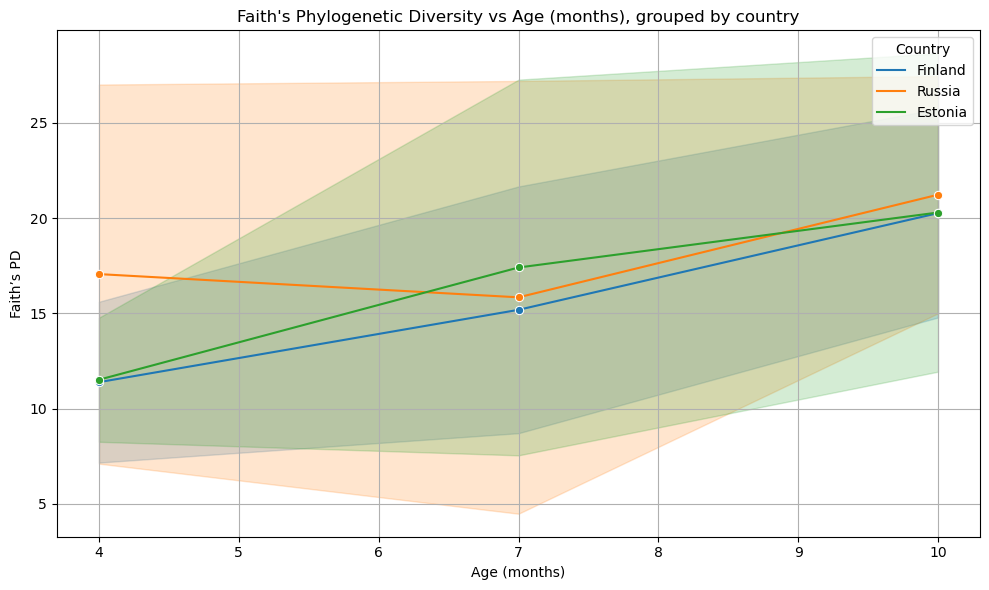

In [30]:

merged = metadata.merge(faith_pd, on="id")

# ----------------------------------------------------------
# 3. Make the line plot (Faith PD vs Age, grouped by country)
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=merged,
    x="age_months",
    y="faith_pd",
    hue="geo_location_name",
    estimator="median",    # median PD per age/country
    errorbar="sd",               # shaded confidence band
    marker="o"
)

plt.title("Faith's Phylogenetic Diversity vs Age (months), grouped by country")
plt.xlabel("Age (months)")
plt.ylabel("Faith’s PD")
plt.legend(title="Country")
plt.grid(True)
plt.tight_layout()
plt.show()

## Background Theory

#### Goal for plot: Phylogenetic diversity over time

- A main outcome could be the visualization of Faith’s PD versus infant age.

##### Objective:
- Quantify how the evolutionary richness of the gut microbiome expands during development and compare this trajectory between countries.

#####  Expected pattern:

- Low Faith’s PD at birth → dominated by few, closely related taxa (e.g., Bifidobacterium).

- Gradual increase as more diverse lineages colonize the gut.

- Differences between countries may reflect environmental and lifestyle factors.

##### Visualization:

- Line plot of Faith’s PD vs. age (months), grouped by country.

- Increasing PD indicates increasing evolutionary complexity and microbial ecosystem maturation.

### Other (ChatGPT) ideas for further analysis

#####  Option A. Add phylogenetic beta diversity trajectories

- Instead of just within-sample PD, examine how each baby’s community moves through phylogenetic space over time using UniFrac distances.
- Questions like:
    - Do Finnish infants converge to a shared “adult-like” community faster than Russian or Estonian infants?
    - Are early-life microbiomes more phylogenetically distinct between countries than later on?

- Output:
    - A PCoA plot (based on UniFrac) with arrows showing each infant’s trajectory.
    - This captures change rather than static richness — much more dynamic.

#####  Option B. Add clade-level dynamics

- Use your tree and metadata to identify which evolutionary lineages change in abundance or appear at specific times.
- For instance:

    - Early dominance of Actinobacteria (esp. Bifidobacterium).

    - Gradual appearance of Firmicutes and Bacteroidota around weaning.

    - Country-specific enrichment of certain Enterobacteriaceae clades.

- Tools:
    - q2-empress, gneiss, or differential abundance testing mapped onto the tree.
    - This tells a story about evolutionary succession.

🌳 1. data_tree.nwk (Newick file)
🌿 2. sepp-tree.qza (QIIME2 artifact — unrooted tree)
🧬 3. sepp-tree-placements.qza (the most biologically interesting SEPP output)

In [ ]:
# This cell also takes quite some time, time to enjoy another coffee (at least 30 minutes)!

# Metadata columns to test
group_columns = ["geo_location_name", "delivery_mode", "diet_milk", "treatment_exposure"]

print("Running beta-group significance tests for selected metadata columns...")

# Beta-group significance analyses (PERMANOVA, ANOSIM, PERMDISP)
# These tests check whether groups differ in community composition
beta_distance_matrices = [
    ("unweighted_unifrac_distance_matrix.qza", "unweighted_unifrac"),
    ("weighted_unifrac_distance_matrix.qza",   "weighted_unifrac"),
    ("jaccard_distance_matrix.qza",            "jaccard"),
    ("bray_curtis_distance_matrix.qza",        "bray_curtis")
]

for dm_file, prefix in beta_distance_matrices:
    dm_path = f"{run_dir}/core_metrics/{dm_file}"   # distance matrix
    
    if os.path.exists(dm_path):

        for group_column in group_columns:          # loop through the selected metadata columns

            # PERMANOVA (default)
            !qiime diversity beta-group-significance \
                --i-distance-matrix {dm_path} \
                --m-metadata-file {metadata} \
                --m-metadata-column {group_column} \
                --o-visualization {run_dir}/core_metrics/{prefix}_permanova_{group_column}.qzv \
                --p-permutations 999

            # ANOSIM
            !qiime diversity beta-group-significance \
                --i-distance-matrix {dm_path} \
                --m-metadata-file {metadata} \
                --m-metadata-column {group_column} \
                --o-visualization {run_dir}/core_metrics/{prefix}_anosim_{group_column}.qzv \
                --p-method anosim \
                --p-permutations 999

            # PERMDISP
            !qiime diversity beta-group-significance \
                --i-distance-matrix {dm_path} \
                --m-metadata-file {metadata} \
                --m-metadata-column {group_column} \
                --o-visualization {run_dir}/core_metrics/{prefix}_permdisp_{group_column}.qzv \
                --p-method permdisp \
                --p-permutations 999

print("Finished beta-group significance tests!")

# Mantel tests 
dm_paths = {
    name: f"{run_dir}/core_metrics/{file}"
    for file, name in [
        ("unweighted_unifrac_distance_matrix.qza", "unweighted"),
        ("weighted_unifrac_distance_matrix.qza",   "weighted"),
        ("jaccard_distance_matrix.qza",            "jaccard"),
        ("bray_curtis_distance_matrix.qza",        "bray")
    ]
}

for (name1, path1), (name2, path2) in itertools.combinations(dm_paths.items(), 2):
    if os.path.exists(path1) and os.path.exists(path2):   # ensure both matrices exist
        output_path = f"{run_dir}/core_metrics/mantel_{name1}_vs_{name2}.qzv"
        
        !qiime diversity mantel \
            --i-dm1 {path1} \
            --i-dm2 {path2} \
            --o-visualization {output_path} \
            --p-permutations 999

print("Finished Mantel tests!")

In [ ]:
# Helper function: draw a confidence ellipse around each group
# This gives a visual impression of how spread out each category is.
def add_confidence_ellipse(ax, x, y, color, alpha=0.20):
    """Draws a 1 SD covariance ellipse around a group's point cloud."""
    
    # We need at least 3 points to calculate a meaningful ellipse
    if len(x) < 3:
        return

    # Convert to floats to avoid issues
    x = x.astype(float)
    y = y.astype(float)

    # Compute covariance matrix and group mean
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)

    # Eigenvectors/eigenvalues give ellipse orientation and spread
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Width and height = 1 standard deviation in each direction
    width, height = 2 * np.sqrt(eigvals)

    # Determine ellipse rotation angle
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    # Create ellipse patch
    ellipse = Ellipse(
        (mean_x, mean_y),
        width, height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=1.4
    )
    ax.add_patch(ellipse)


# Load PCoA results and merge with metadata
# This function extracts the first two axes (PC1 and PC2)
# and also attaches the metadata column we want to color by.
def load_pcoa(metric_file, metadata_df, column):
    """Loads PCoA coordinates, variance explained, and merges with metadata."""

    # Load QIIME2 PCoA artifact and convert to skbio OrdinationResults
    pcoa_art = Artifact.load(metric_file)
    pcoa = pcoa_art.view(OrdinationResults)

    # Extract coordinates
    coords = pcoa.samples.copy()
    coords.index.name = "SampleID"
    coords = coords.iloc[:, :2]     # Keep only PC1 and PC2
    coords.columns = ["PC1", "PC2"]

    # Variance explained for axis labels
    var_exp = pcoa.proportion_explained.iloc[:2].values

    # Merge metadata column of interest
    df = coords.join(metadata_df[column], how="inner")
    df = df.dropna(subset=[column])

    # Convert to a clean categorical variable
    df[column] = df[column].astype(str).str.strip()
    df[column] = df[column].astype("category")

    return df, var_exp


# Plot one PCoA panel for a single beta-diversity metric.
# This includes scatter points, centroids, and confidence ellipses.
def plot_single_pcoa(ax, df, var_exp, column, metric_name,
                     centroid_marker="X", axis_title_size=13):

    unique_groups = list(df[column].cat.categories)

    # Use a consistent color palette to make subplots comparable.
    base_colors = ["#0072B2", "#E69F00", "#009E73"]
    if len(unique_groups) <= len(base_colors):
        palette_list = base_colors[:len(unique_groups)]
    else:
        extra = sns.color_palette("colorblind", n_colors=len(unique_groups) - len(base_colors))
        palette_list = base_colors + list(extra)

    color_map = {g: palette_list[i] for i, g in enumerate(unique_groups)}

    # Scatterplot of samples
    sns.scatterplot(
        ax=ax,
        data=df,
        x="PC1", y="PC2",
        hue=column,
        hue_order=unique_groups,
        palette=color_map,
        s=60,
        alpha=0.85
    )

    # Draw ellipses and group centroids
    for group, sub in df.groupby(column):
        x = sub["PC1"].astype(float)
        y = sub["PC2"].astype(float)

        # Add ellipse for that group
        add_confidence_ellipse(ax, x, y, color_map[group])

        # Plot the centroid of the group
        ax.scatter(
            np.mean(x), np.mean(y),
            color=color_map[group],
            s=300,
            marker=centroid_marker,
            edgecolor="black",
            linewidth=0.7,
            zorder=5
        )

    # Label axes using the % variance explained
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
    ax.set_title(metric_name, fontsize=axis_title_size)
    ax.grid(alpha=0.3)


# Plot four PCoA plots (one per metric) in a 2×2 layout.
# The idea is to compare how different beta-diversity metrics
# separate the same metadata groups.
def plot_all_metrics_for_column(
        column,
        legend_title=None,
        figure_title=None,
        centroid_marker="X",
        legend_position="lower center",
        rename_dict=None,
        metric_labels=None
    ):

    # Files corresponding to the four beta-diversity metrics
    metric_files = {
        "Jaccard": f"{beta_metrics_dir}/jaccard_pcoa_results.qza",
        "Bray–Curtis": f"{beta_metrics_dir}/bray_curtis_pcoa_results.qza",
        "Unweighted UniFrac": f"{beta_metrics_dir}/unweighted_unifrac_pcoa_results.qza",
        "Weighted UniFrac": f"{beta_metrics_dir}/weighted_unifrac_pcoa_results.qza"
    }

    # Create a 2x2 grid for the four PCoA scatterplots
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    # Loop through each metric and plot its PCoA result
    for ax, (metric_name, file_path) in zip(axes, metric_files.items()):
        df, var_exp = load_pcoa(file_path, metadata_df, column)

        # Optionally rename groups (e.g., "0"/"1" → "Control"/"Treatment")
        if rename_dict is not None:
            df[column] = df[column].replace(rename_dict)
            df[column] = df[column].astype("category")

        # Optional metric name overrides
        plot_title = metric_labels.get(metric_name, metric_name) if metric_labels else metric_name

        plot_single_pcoa(
            ax=ax,
            df=df,
            var_exp=var_exp,
            column=column,
            metric_name=plot_title,
            centroid_marker=centroid_marker
        )

    # Extract legend elements from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()

    # Remove per-panel legends to avoid clutter
    for ax in axes:
        ax.legend().remove()

    # Create a single shared legend for all plots
    if len(handles) > 0 and len(labels) > 0:
        if rename_dict is not None:
            labels = [rename_dict.get(l, l) for l in labels]

        legend_title = legend_title if legend_title else column

        fig.legend(
            handles, labels,
            title=legend_title,
            loc=legend_position,
            ncol=len(labels),
            frameon=False
        )

    # Global figure title
    final_title = figure_title if figure_title else (
        f"PCoA Comparison Across Metrics\nColored by '{column}'"
    )
    fig.suptitle(final_title, fontsize=18)

    # Adjust layout so title and legend are well spaced
    plt.tight_layout(rect=(0, 0.03, 1, 0.98))
    plt.show()

In [ ]:
# Metric labels used to give cleaner titles to the PCoA plots.
# This helps make the figures easier to read and compare.
metric_labels = {
    "Bray–Curtis": "Bray–Curtis Dissimilarity",
    "Jaccard": "Jaccard Index",
    "Unweighted UniFrac": "Unweighted UniFrac Distance",
    "Weighted UniFrac": "Weighted UniFrac Distance"
}

# Rename dictionaries for the metadata categories we want to visualize.
# These make the plot legends more interpretable.
rename_milk = {
    "bd": "Breast milk",
    "fd": "Formula",
    "mixed": "Mixed"
}

# Example rename dictionary for weaning categories.
# Replace these values with the actual labels from the metadata if needed.
rename_weaning = {
    "yes": "Yes",
    "no": "No"
}

# age_months is numeric, so we do not need a rename dictionary for it.


# ----- Plot 1: diet_milk -----
# Here we visualize how samples cluster across different beta diversity metrics
# when colored by milk type. This is one of the variables that changes over time,
# so we can meaningfully interpret the patterns.
print("\n" + "="*80)
print("PCoA PLOTS FOR: diet_milk")
print("="*80)

plot_all_metrics_for_column(
    column="diet_milk",
    rename_dict=rename_milk,
    metric_labels=metric_labels,
    legend_title="Milk Type",
    legend_position="lower center",
    figure_title="Beta Diversity – Milk Type",
    centroid_marker="o"
)


# ----- Plot 2: diet_weaning -----
# Same idea as above, but now focusing on weaning diet. This variable also changes
# across timepoints, so visualizing it can give us hints about how microbiome
# composition shifts with solid food introduction.
print("\n" + "="*80)
print("PCoA PLOTS FOR: diet_weaning")
print("="*80)

plot_all_metrics_for_column(
    column="diet_weaning",
    rename_dict=rename_weaning,
    metric_labels=metric_labels,
    legend_title="Weaning Diet",
    legend_position="lower center",
    figure_title="Beta Diversity – Weaning Diet",
    centroid_marker="o"
)


# ----- Plot 3: age_months -----
# Age is continuous, so this plot helps show how samples move along gradients
# as infants grow older. We use the same plotting function but without renaming.
print("\n" + "="*80)
print("PCoA PLOTS FOR: age_months")
print("="*80)

plot_all_metrics_for_column(
    column="age_months",
    rename_dict=None,  # numeric variable
    metric_labels=metric_labels,
    legend_title="Age (months)",
    legend_position="lower center",
    figure_title="Beta Diversity – Age in Months",
    centroid_marker="o"
)
